# 03 · Feature engineering, folds and leakage checks

This notebook defines exactly what every model sees, and proves it programmatically before any model is trained.

| | |
|---|---|
| **Inputs** | `processed/cells/*.parquet`, `processed/cell_summary.csv` |
| **Outputs** | `processed/folds.csv`, `processed/origins.csv`, `processed/feature_dictionary.csv`, `processed/training_sets.csv`, `processed/leakage_checks.csv`, `figures/03_*.png` |

### Design rules, carried over from the sales-forecasting project's review

1. **Horizon parity.** Every model forecasts the same *H* cycles from the same window of *L* past cycles, and all
   models reach end of life through one roll-out engine. No model ever sees a capacity value after the forecast origin.
2. **Information parity.** The linear models read the raw window; the tree models read the *same* window summarised
   as features. No feature uses anything outside the window — in particular no cycle index, which would hand the trees
   a cell's age.
3. **Split by cell, never by time.** Leave-one-cell-out within each dataset; a model never sees any part of the cell
   it is tested on.
4. **Fit every transform on training cells only.** The linear models' scaler is fitted on the fold's training windows.

In [1]:
# Make the repository importable, locally or on Google Colab.
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    # Once per session:
    #   !git clone https://github.com/<your-account>/battery-rul-linear.git /content/battery-rul-linear
    #   %pip install -q -r /content/battery-rul-linear/requirements.txt
    # Raw data on Drive: MyDrive/battery_rul/data/NASA_PCoE/*.mat and .../CALCE_CX2/CX2_*/
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/battery-rul-linear")
    os.environ.setdefault("BATTERY_RUL_DATA", "/content/drive/MyDrive/battery_rul/data")

ROOT = Path.cwd().resolve()
if not (ROOT / "battery_rul").is_dir():
    ROOT = ROOT.parent                          # launched from notebooks/
os.environ.setdefault("BATTERY_RUL_ROOT", str(ROOT))
sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from battery_rul import config
from battery_rul.cleaning import clean_capacity
from battery_rul.dataset import cells_by_dataset, forecast_origins, load_cells, loco_folds, rollout_cap
from battery_rul.features import (Standardizer, build_training_set, make_targets, make_windows, window_at,
                                  window_features)
from battery_rul.plotting import INK, INK_2, MUTED, savefig, setup_style
from battery_rul.utils import record_run, save_table

pd.set_option("display.width", 160)
setup_style()
record_run("03_feature_engineering")
cells = load_cells()
REF = config.LABELS.primary_reference
folds = loco_folds(cells, REF)
print(f"{len(cells)} cells, {len(folds)} leave-one-cell-out folds")
for ds, w in config.WINDOWS.items():
    print(f"{ds}: L = {w.input_len}, H = {w.horizon}, DLinear moving-average kernel = {w.ma_kernel}")

11 cells, 11 leave-one-cell-out folds
NASA: L = 16, H = 8, DLinear moving-average kernel = 5
CALCE: L = 48, H = 16, DLinear moving-average kernel = 13


## 1. Folds

Each cell that reaches end of life is the test cell of exactly one fold. Its training set is every other cell of the
same dataset — including cells that never reach end of life, whose trajectories are still informative.

In [3]:
fold_table = pd.DataFrame([{"fold": f.fold_id, "dataset": f.dataset, "test_cell": f.test,
                            "train_cells": " ".join(f.train), "n_train_cells": len(f.train),
                            "rollout_cap": rollout_cap([cells[n] for n in f.train], REF)} for f in folds])
fold_table.to_csv(config.PROCESSED_DIR / "folds.csv", index=False)
fold_table

,fold,dataset,test_cell,train_cells,n_train_cells,rollout_cap
0,CALCE:CX2_16,CALCE,CX2_16,CX2_33 CX2_34 CX2_35 CX2_36 CX2_37 CX2_38,6,1254
1,CALCE:CX2_33,CALCE,CX2_33,CX2_16 CX2_34 CX2_35 CX2_36 CX2_37 CX2_38,6,1500
2,CALCE:CX2_34,CALCE,CX2_34,CX2_16 CX2_33 CX2_35 CX2_36 CX2_37 CX2_38,6,1500
3,CALCE:CX2_35,CALCE,CX2_35,CX2_16 CX2_33 CX2_34 CX2_36 CX2_37 CX2_38,6,1500
4,CALCE:CX2_36,CALCE,CX2_36,CX2_16 CX2_33 CX2_34 CX2_35 CX2_37 CX2_38,6,1500
5,CALCE:CX2_37,CALCE,CX2_37,CX2_16 CX2_33 CX2_34 CX2_35 CX2_36 CX2_38,6,1500
6,CALCE:CX2_38,CALCE,CX2_38,CX2_16 CX2_33 CX2_34 CX2_35 CX2_36 CX2_37,6,1500
7,NASA:B0005,NASA,B0005,B0006 B0007 B0018,3,141
8,NASA:B0006,NASA,B0006,B0005 B0007 B0018,3,141
9,NASA:B0007,NASA,B0007,B0005 B0006 B0018,3,111


## 2. Forecast origins

Forecasts are made at 25%, 50% and 75% of each test cell's true life. An origin is kept only if at least *L* cycles
have been observed; skipped origins are reported here as coverage rather than silently dropped. The unit of
replication for every statistical test is a (cell, origin) pair.

In [4]:
orig_rows = []
for f in folds:
    L = config.WINDOWS[f.dataset].input_len
    kept = {o.frac: o for o in forecast_origins(cells[f.test], L, REF)}
    for frac in config.ORIGIN_FRACS:
        o = kept.get(frac)
        orig_rows.append({"dataset": f.dataset, "cell": f.test, "frac": frac,
                          "t0": o.t0 if o else np.nan, "true_eol": cells[f.test].eol[REF],
                          "true_rul": o.true_rul if o else np.nan, "kept": o is not None})
origins = pd.DataFrame(orig_rows)
origins.to_csv(config.PROCESSED_DIR / "origins.csv", index=False)
print(origins.groupby("dataset")["kept"].agg(["sum", "count"]).rename(columns={"sum": "kept", "count": "possible"}))
origins

         kept  possible
dataset                
CALCE      21        21
NASA       11        12


,dataset,cell,frac,t0,true_eol,true_rul,kept
0,CALCE,CX2_16,0.25,250.0,1000,750.0,True
1,CALCE,CX2_16,0.50,500.0,1000,500.0,True
2,CALCE,CX2_16,0.75,750.0,1000,250.0,True
3,CALCE,CX2_33,0.25,155.0,621,466.0,True
4,CALCE,CX2_33,0.50,310.0,621,311.0,True
5,CALCE,CX2_33,0.75,466.0,621,155.0,True
6,CALCE,CX2_34,0.25,165.0,661,496.0,True
7,CALCE,CX2_34,0.50,330.0,661,331.0,True
8,CALCE,CX2_34,0.75,496.0,661,165.0,True
9,CALCE,CX2_35,0.25,209.0,836,627.0,True


## 3. One window, illustrated

The input window (cycles *t0 − L + 1 … t0*) and the target (the next *H* cycles) for one training cell.

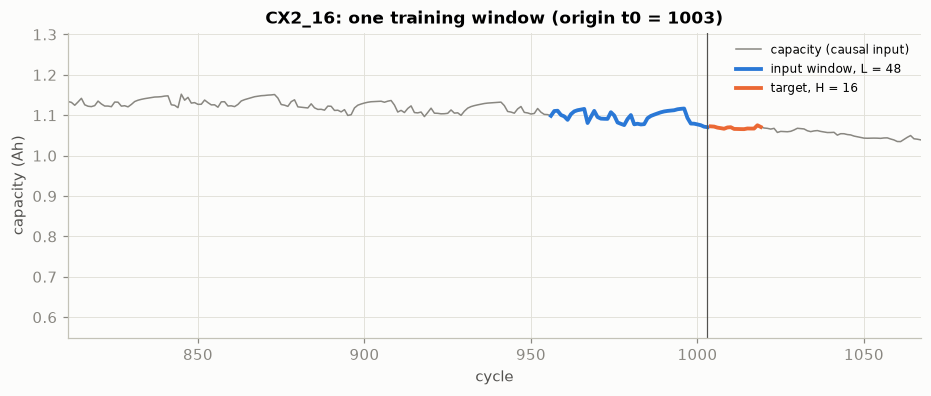

In [5]:
name = sorted(cells, key=lambda n: (cells[n].dataset != "CALCE", n))[0]
cell = cells[name]
w = config.WINDOWS[cell.dataset]
t0 = cell.n_cycles // 2
fig, ax = plt.subplots(figsize=(10, 3.6))
cyc = np.arange(1, cell.n_cycles + 1)
ax.plot(cyc, cell.capacity, color=MUTED, lw=1, label="capacity (causal input)")
ax.plot(cyc[t0 - w.input_len:t0], cell.capacity[t0 - w.input_len:t0], color="#2a78d6", lw=2.5,
        label=f"input window, L = {w.input_len}")
ax.plot(cyc[t0:t0 + w.horizon], cell.capacity[t0:t0 + w.horizon], color="#eb6834", lw=2.5,
        label=f"target, H = {w.horizon}")
ax.axvline(t0, color=INK_2, lw=0.8)
ax.set(xlim=(t0 - 4 * w.input_len, t0 + 4 * w.horizon), title=f"{name}: one training window (origin t0 = {t0})",
       xlabel="cycle", ylabel="capacity (Ah)")
ax.legend(fontsize=8)
savefig(fig, "03_window_example")
plt.show()

## 4. Tree features

Two variants, tied to the tree target mode:

* **absolute** — level features in Ah plus shape features; targets are future capacities in Ah. Standard practice.
  A tree cannot predict outside the range of targets it saw in training.
* **delta** — level features expressed relative to the last observed value, plus the same shape features; targets are
  changes from the last value. No absolute level anywhere: the tree analogue of NLinear's normalisation.

Comparing the two in RQ2 separates *model family* from *target normalisation* — the confound that let a preprocessing
choice partly decide the model comparison in the sales-forecasting project.

In [6]:
X, Y, _ = make_windows(cell.capacity, w.input_len, w.horizon)
feat_abs = window_features(X, level_relative=False)
feat_rel = window_features(X, level_relative=True)

DESCRIPTIONS = {
    "cap_last": "last observed capacity", "cap_first": "first capacity in window", "cap_mean": "window mean",
    "cap_median": "window median", "cap_min": "window minimum", "cap_max": "window maximum",
    "slope": "least-squares slope over the window", "curvature": "quadratic coefficient over the window",
    "cap_std": "standard deviation", "cap_range": "max - min", "fade_total": "first - last",
    "diff_mean": "mean cycle-to-cycle change", "diff_std": "std of changes", "diff_min": "largest drop",
    "diff_max": "largest rise (regeneration)", "n_increases": "number of rises in the window",
}
def describe(col):
    base = col.replace("_rel", "")
    if base.startswith("lag_"):
        return f"capacity {base.split('_')[1]} cycles before the end of the window"
    for prefix, text in (("roll_mean_", "mean of the last {} cycles"), ("roll_std_", "std of the last {} cycles"),
                         ("roll_slope_", "slope of the last {} cycles")):
        if base.startswith(prefix):
            return text.format(base[len(prefix):])
    return DESCRIPTIONS.get(base, "")

shape_cols = [c for c in feat_abs.columns if c in feat_rel.columns]
dictionary = pd.DataFrame(
    [{"feature": c, "mode": "absolute", "kind": "shape" if c in shape_cols else "level", "description": describe(c)}
     for c in feat_abs.columns] +
    [{"feature": c, "mode": "delta", "kind": "shape" if c in shape_cols else "level (relative to last)",
      "description": describe(c) + (" minus the last value" if c.endswith("_rel") else "")} for c in feat_rel.columns])
dictionary.to_csv(config.PROCESSED_DIR / "feature_dictionary.csv", index=False)
print(f"absolute mode: {feat_abs.shape[1]} features | delta mode: {feat_rel.shape[1]} features "
      f"(L = {w.input_len})")
dictionary

absolute mode: 33 features | delta mode: 32 features (L = 48)


,feature,mode,kind,description
0,cap_last,absolute,level,last observed capacity
1,cap_first,absolute,level,first capacity in window
2,cap_mean,absolute,level,window mean
3,cap_median,absolute,level,window median
4,cap_min,absolute,level,window minimum
...,...,...,...,...
60,roll_slope_10,delta,shape,slope of the last 10 cycles
61,roll_std_20,delta,shape,std of the last 20 cycles
62,roll_slope_20,delta,shape,slope of the last 20 cycles
63,roll_std_40,delta,shape,std of the last 40 cycles


### Which features carry information about the far horizon?

Spearman correlation between each feature and the target at the last horizon step, on one cell's windows.
Descriptive only — it shows why the two modes behave differently: in absolute mode, level features dominate; in delta
mode, the target is a change and shape features take over.

In [7]:
from scipy.stats import spearmanr

def target_corr(F, T):
    return pd.Series({c: spearmanr(F[c], T[:, -1]).statistic for c in F.columns}).sort_values(key=np.abs,
                                                                                            ascending=False)
corr = pd.DataFrame({"absolute": target_corr(feat_abs, make_targets(X, Y, "absolute")).head(8).round(3)})
corr_d = pd.DataFrame({"delta": target_corr(feat_rel, make_targets(X, Y, "delta")).head(8).round(3)})
display(corr)
display(corr_d)

,absolute
cap_min,0.960
cap_mean,0.959
roll_mean_40,0.958
cap_median,0.957
roll_mean_20,0.955
lag_20,0.952
cap_max,0.948
cap_first,0.947


,delta
roll_mean_40_rel,0.605
cap_mean_rel,0.599
roll_mean_20_rel,0.594
cap_median_rel,0.582
lag_20_rel,0.532
roll_slope_20,-0.516
roll_mean_10_rel,0.502
cap_first_rel,0.502


## 5. Training-set sizes per fold

Windows available per fold under the default geometry, for full-range training and for the RQ2 range-restricted arm.

In [8]:
ts_rows = []
for f in folds:
    wc = config.WINDOWS[f.dataset]
    train = [cells[n] for n in f.train]
    full = build_training_set(train, wc.input_len, wc.horizon, reference=REF)
    rest = build_training_set(train, wc.input_len, wc.horizon, reference=REF,
                              range_restrict_soh=config.RANGE_RESTRICT_SOH)
    ts_rows.append({"fold": f.fold_id, "fit_windows": len(full.X_fit), "val_windows": len(full.X_val),
                    "restricted_windows": rest.n_windows, "removed_by_restriction": rest.n_removed_by_range,
                    "train_target_min_Ah": full.Y_all.min(), "restricted_target_min_Ah": rest.Y_all.min()})
training_sets = pd.DataFrame(ts_rows)
training_sets.to_csv(config.PROCESSED_DIR / "training_sets.csv", index=False)
training_sets

,fold,fit_windows,val_windows,restricted_windows,removed_by_restriction,train_target_min_Ah,restricted_target_min_Ah
0,CALCE:CX2_16,8021,2006,2550,7477,0.191416,1.147512
1,CALCE:CX2_33,8276,2070,2868,7478,0.191416,1.147512
2,CALCE:CX2_34,8245,2062,2813,7494,0.191416,1.147512
3,CALCE:CX2_35,8183,2047,2697,7533,0.191416,1.147596
4,CALCE:CX2_36,8058,2015,2947,7126,0.191416,1.147512
5,CALCE:CX2_37,8607,2153,2777,7983,0.191416,1.147512
6,CALCE:CX2_38,8066,2017,2836,7247,0.541421,1.147512
7,NASA:B0005,319,80,77,322,1.153818,1.702408
8,NASA:B0006,319,80,83,316,1.287453,1.700311
9,NASA:B0007,319,80,71,328,1.153818,1.700311


## 6. Leakage and parity checks

Each check is computed on the real processed cells and asserted. If any fails, the notebook stops here and nothing
downstream should be trusted.

In [9]:
checks = []

def check(name, passed, detail=""):
    checks.append({"check": name, "passed": bool(passed), "detail": detail})

# (a) the causal input series has no look-ahead, on every study cell
worst = 0.0
for c in cells.values():
    raw = pd.read_parquet(config.PROCESSED_DIR / "cells" / f"{c.name}.parquet")
    t = c.n_cycles // 2
    x = raw["capacity_raw"].to_numpy().copy()
    x_alt = x.copy()
    x_alt[t + 1:] -= 0.3 * c.references["rated"]
    a, _ = clean_capacity(pd.DataFrame({"capacity_Ah": x}), c.name)
    b, _ = clean_capacity(pd.DataFrame({"capacity_Ah": x_alt}), c.name)
    worst = max(worst, float(np.max(np.abs(a["capacity_input"][:t + 1].to_numpy() -
                                           b["capacity_input"][:t + 1].to_numpy()))))
check("causal input unaffected by future values (all cells)", worst == 0.0, f"max change {worst:.2e} Ah")

# (b) a test cell never appears in its own training set
check("test cell never in its training set", all(f.test not in f.train for f in folds))

# (c) folds never mix datasets
check("folds never mix datasets", all(all(cells[n].dataset == f.dataset for n in f.train) for f in folds))

# (d) origin windows end exactly at t0
ok = True
for f in folds:
    L = config.WINDOWS[f.dataset].input_len
    for o in forecast_origins(cells[f.test], L, REF):
        win = window_at(cells[f.test].capacity, o.t0, L)
        ok &= np.array_equal(win, cells[f.test].capacity[o.t0 - L:o.t0])
check("origin windows end at t0 (cycles t0-L+1..t0)", ok)

# (e) features contain no cycle index or absolute time
cols = set(window_features(X, False).columns) | set(window_features(X, True).columns)
check("no cycle index among tree features", not any(k in c for c in cols for k in ("cycle", "end", "time")))

# (f) delta-mode features are shift-invariant (carry no absolute level)
check("delta-mode features invariant to a level shift",
      np.allclose(window_features(X, True).to_numpy(), window_features(X + 0.25, True).to_numpy()))

# (g) the scaler is fitted on training windows only
f0 = folds[0]
wc = config.WINDOWS[f0.dataset]
ts = build_training_set([cells[n] for n in f0.train], wc.input_len, wc.horizon, reference=REF)
sc = Standardizer().fit(ts.X_fit)
check("scaler statistics come from training windows only",
      np.isclose(sc.mean_, ts.X_fit.mean()) and not np.isclose(sc.mean_, cells[f0.test].capacity.mean()),
      f"train mean {sc.mean_:.4f} vs test-cell mean {cells[f0.test].capacity.mean():.4f}")

# (h) range restriction really removes the end-of-life region
ok = all(r["restricted_target_min_Ah"] >= config.RANGE_RESTRICT_SOH * 0.999 *
         min(cells[n].references[REF] for n in f.train)
         for r, f in zip(ts_rows, folds))
check("range-restricted training targets stay above the SoH floor", ok)

leakage = pd.DataFrame(checks)
leakage.to_csv(config.PROCESSED_DIR / "leakage_checks.csv", index=False)
display(leakage)
assert leakage["passed"].all(), "leakage / parity check failed - do not proceed"

,check,passed,detail
0,causal input unaffected by future values (all ...,True,max change 0.00e+00 Ah
1,test cell never in its training set,True,
2,folds never mix datasets,True,
3,origin windows end at t0 (cycles t0-L+1..t0),True,
4,no cycle index among tree features,True,
5,delta-mode features invariant to a level shift,True,
6,scaler statistics come from training windows only,True,train mean 1.0782 vs test-cell mean 1.0753
7,range-restricted training targets stay above t...,True,


## 7. Summary

In [10]:
print(f"{len(folds)} folds | {int(origins['kept'].sum())}/{len(origins)} origins usable | "
      f"{int(leakage['passed'].sum())}/{len(leakage)} leakage and parity checks passed")
for ds, g in training_sets.assign(ds=training_sets["fold"].str.split(":").str[0]).groupby("ds"):
    print(f"{ds}: {g['fit_windows'].median():.0f} fit + {g['val_windows'].median():.0f} validation windows per fold "
          f"(median); range restriction removes {g['removed_by_restriction'].median():.0f}")
print("next: 04_modelling_linears.ipynb (RQ1)")

11 folds | 32/33 origins usable | 8/8 leakage and parity checks passed
CALCE: 8183 fit + 2047 validation windows per fold (median); range restriction removes 7478
NASA: 319 fit + 80 validation windows per fold (median); range restriction removes 324
next: 04_modelling_linears.ipynb (RQ1)
